<a href="https://colab.research.google.com/github/stevefreund88-collab/hello-lab/blob/main/exercise_3_1_decision_boundary_visualization_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 3.1: Decision Boundary Visualization

## Learning Objectives

By completing this exercise, you will:

- Understand how classifiers separate different classes in 2D space
- Visualize decision boundaries for multiple algorithms
- Compare linear vs. non-linear decision boundaries
- Develop geometric intuition about classification
- Learn to create interactive classification visualizations

---

## The Problem: Email Spam Detection

You're building a spam filter. To understand how classification works, you'll analyze emails based on just two features:

- **Feature 1:** Number of exclamation marks (!!!)
- **Feature 2:** Percentage of words that are "suspicious" (free, urgent, winner, etc.)

Your task: Visualize how different machine learning algorithms draw boundaries between spam and legitimate emails.

---

## Setup: Import Required Libraries

In [3]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

---

## Part A: Create and Visualize the Dataset

### Step 1: Generate Synthetic Email Data

In [8]:
# Set random seed for reproducibility
np.random.seed(42)

# Create legitimate emails (Class 0)
legitimate_exclamation = np.random.normal(1, 0.8, 50)  # Few exclamation marks
legitimate_suspicious = np.random.normal(5, 3, 50)     # Few suspicious words

# Create spam emails (Class 1)
spam_exclamation = np.random.normal(4, 1.2, 50)        # Many exclamation marks
spam_suspicious = np.random.normal(15, 4, 50)          # Many suspicious words

# Combine into arrays
X = np.vstack([
    np.column_stack([legitimate_exclamation, legitimate_suspicious]),
    np.column_stack([spam_exclamation, spam_suspicious])
])

# Labels: 0 = Legitimate, 1 = Spam
y = np.array([0]*50 + [1]*50)

# Create DataFrame for easy viewing
df = pd.DataFrame(X, columns=['exclamation_marks', 'suspicious_words_pct'])
df['label'] = y
df['label_name'] = df['label'].map({0: 'Legitimate', 1: 'Spam'})

print("Dataset Preview:")
print(df.head(10))
print(f"\nTotal samples: {len(df)}")
print(f"Legitimate emails: {(y==0).sum()}")
print(f"Spam emails: {(y==1).sum()}")

Dataset Preview:
   exclamation_marks  suspicious_words_pct  label  label_name
0           1.397371              5.972252      0  Legitimate
1           0.889389              3.844753      0  Legitimate
2           1.518151              2.969234      0  Legitimate
3           2.218424              6.835029      0  Legitimate
4           0.812677              8.092999      0  Legitimate
5           0.812690              7.793840      0  Legitimate
6           2.263370              2.482347      0  Legitimate
7           1.613948              4.072363      0  Legitimate
8           0.624420              5.993790      0  Legitimate
9           1.434048              7.926635      0  Legitimate

Total samples: 100
Legitimate emails: 50
Spam emails: 50


### Step 2: Visualize the Raw Data

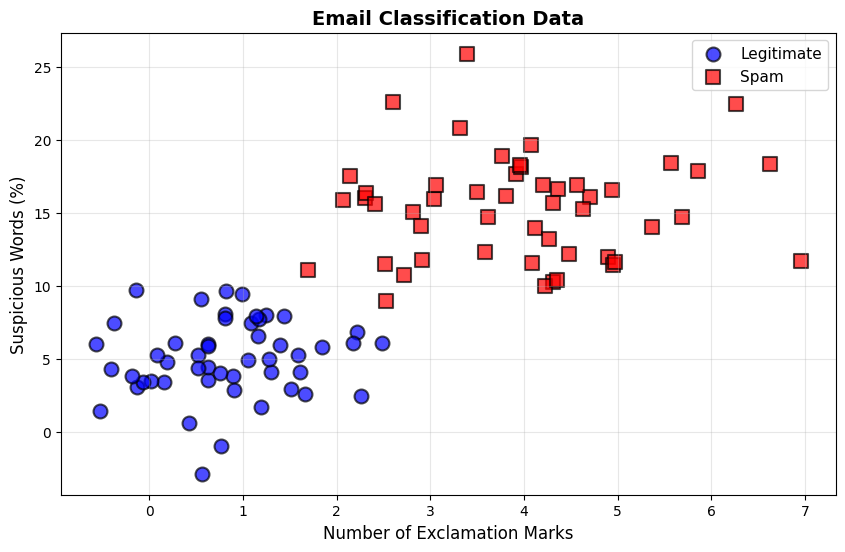

In [9]:
plt.figure(figsize=(10, 6))

# Plot legitimate emails
plt.scatter(X[y==0, 0], X[y==0, 1],
           c='blue', marker='o', s=100, alpha=0.7,
           edgecolors='black', label='Legitimate', linewidth=1.5)

# Plot spam emails
plt.scatter(X[y==1, 0], X[y==1, 1],
           c='red', marker='s', s=100, alpha=0.7,
           edgecolors='black', label='Spam', linewidth=1.5)

plt.xlabel('Number of Exclamation Marks', fontsize=12)
plt.ylabel('Suspicious Words (%)', fontsize=12)
plt.title('Email Classification Data', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

**Question 1:** Looking at the scatter plot, can you visually identify where you would draw a line to separate spam from legitimate emails? Describe where this line would go.

*Your answer:* _Yes, there are two distince regions.  The legitimate emails represented by blue cicles are completely seperate and distinct from the spam represetned by red boxes. The curved line would go from 11% to 2.5.

**Question 2:** Do the two classes appear completely separable, or is there some overlap? What does this mean for classification accuracy?

*Your answer:* Yes, they are completely seperate with no overlap.It seems to indicate that the system is able to differenciate the two data groupings which would mean no mistakes.

---

## Part B: Understanding Decision Boundaries

A **decision boundary** is the line (or curve) that separates different classes. Points on one side are predicted as one class, points on the other side as another class.

### Concept Visualization

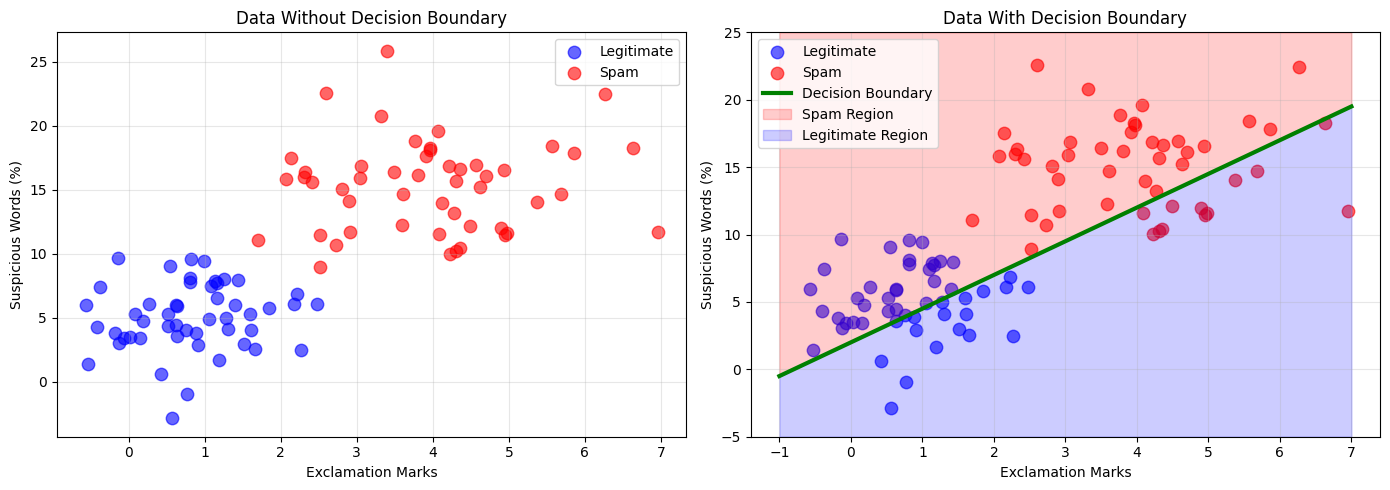

In [11]:
# Simple illustration of decision boundary concept
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Just the data
axes[0].scatter(X[y==0, 0], X[y==0, 1], c='blue', s=80, alpha=0.6, label='Legitimate')
axes[0].scatter(X[y==1, 0], X[y==1, 1], c='red', s=80, alpha=0.6, label='Spam')
axes[0].set_xlabel('Exclamation Marks')
axes[0].set_ylabel('Suspicious Words (%)')
axes[0].set_title('Data Without Decision Boundary')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right plot: Data with a manual boundary line
axes[1].scatter(X[y==0, 0], X[y==0, 1], c='blue', s=80, alpha=0.6, label='Legitimate')
axes[1].scatter(X[y==1, 0], X[y==1, 1], c='red', s=80, alpha=0.6, label='Spam')

# Draw a hypothetical decision boundary
x_boundary = np.linspace(-1, 7, 100)
y_boundary = 2.5 * x_boundary + 2  # A diagonal line
axes[1].plot(x_boundary, y_boundary, 'g-', linewidth=3, label='Decision Boundary')

# Shade regions
axes[1].fill_between(x_boundary, y_boundary, 25, alpha=0.2, color='red', label='Spam Region')
axes[1].fill_between(x_boundary, -5, y_boundary, alpha=0.2, color='blue', label='Legitimate Region')

axes[1].set_xlabel('Exclamation Marks')
axes[1].set_ylabel('Suspicious Words (%)')
axes[1].set_title('Data With Decision Boundary')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(-5, 25)

plt.tight_layout()
plt.show()

**Question 3:** In the right plot, what prediction would the model make for an email with 3 exclamation marks and 10% suspicious words? How can you tell?

*Your answer:* _This would indicate span.  There are no blue lines higher than 2.5 and all but 1 of the red dots are above 2.

---

## Part C: Helper Function for Plotting Decision Boundaries

This function creates a mesh grid and plots decision boundaries:

In [16]:
def plot_decision_boundary(model, X, y, title, ax=None):
    """
    Plot decision boundary for a trained classifier.

    Parameters:
    - model: trained classifier with predict() method
    - X: feature array (n_samples, 2)
    - y: labels array (n_samples,)
    - title: plot title
    - ax: matplotlib axis (optional)
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))

    # Create a mesh grid
    h = 0.1  # step size in the mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # Predict on each point in the mesh
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot the contour (decision boundary)
    colors = ListedColormap(['#AAAAFF', '#FFAAAA'])
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=colors)
    ax.contour(xx, yy, Z, colors='green', linewidths=2)

    # Plot the training points
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap=ListedColormap(['blue', 'red']),
                         s=100, alpha=0.7, edgecolors='black', linewidth=1.5)

    ax.set_xlabel('Exclamation Marks', fontsize=11)
    ax.set_ylabel('Suspicious Words (%)', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

    return ax

print("Helper function loaded successfully!")

Helper function loaded successfully!


**Question 4:** Look at the helper function code. What is the purpose of creating a "mesh grid"? Why do we need to predict on so many points?

*Your answer:* _A mesh grid helps to view the data by viewing it in context wtih a standardized background with grid elemetns.

---

## Part D: Logistic Regression (Linear Boundary)

Let's start with logistic regression, which creates a **linear** (straight) decision boundary:

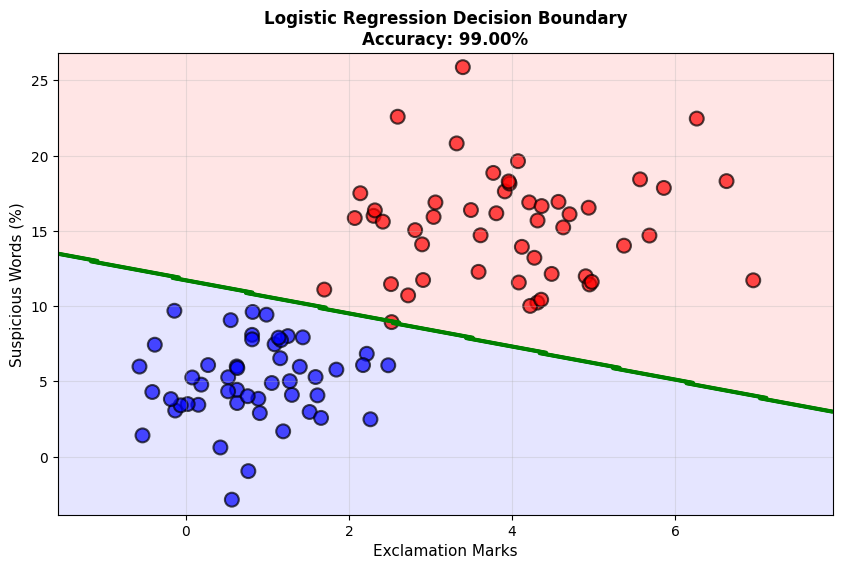

Logistic Regression Accuracy: 99.00%


In [18]:
# Train logistic regression
log_reg = LogisticRegression()
log_reg.fit(X, y)

# Calculate accuracy
y_pred = log_reg.predict(X)
accuracy = accuracy_score(y, y_pred)

# Plot
plot_decision_boundary(log_reg, X, y,
                       f'Logistic Regression Decision Boundary\nAccuracy: {accuracy:.2%}')
plt.show()

print(f"Logistic Regression Accuracy: {accuracy:.2%}")

**Question 5:** Describe the shape of the decision boundary for logistic regression. Is it straight or curved? Why?

*Your answer:* _The decision boundry is a straight line that goes from around 14% down to less than 4%. All data elements can fit within these parameters.

**Question 6:** Are there any points that are misclassified (on the wrong side of the boundary)? Circle them mentally and explain why they might be misclassified.

*Your answer:* _All data points fit within the parameters identified by the line.

---

## Part E: Decision Tree (Non-Linear Boundary)

Decision trees create **axis-aligned** boundaries (only vertical and horizontal splits):

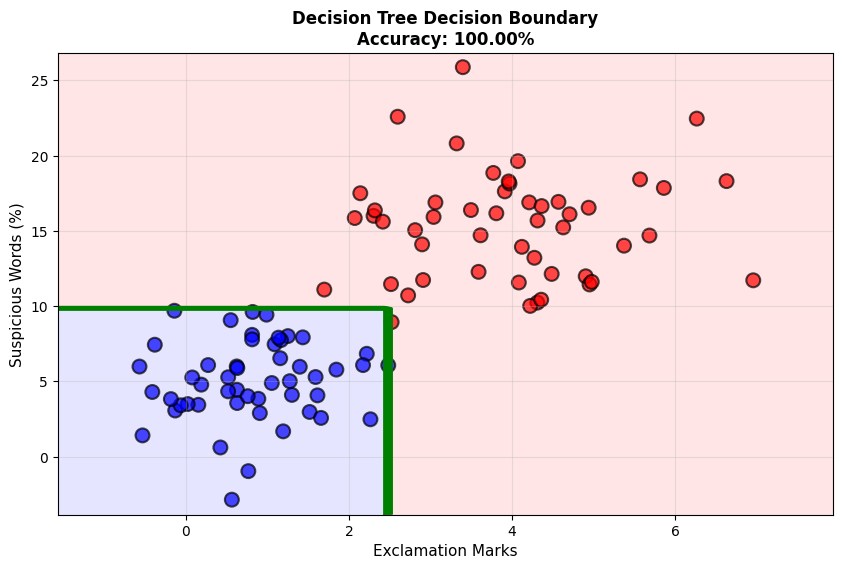

Decision Tree Accuracy: 100.00%


In [23]:
# Train decision tree
tree = DecisionTreeClassifier(max_depth=10, random_state=42)
tree.fit(X, y)

# Calculate accuracy
y_pred_tree = tree.predict(X)
accuracy_tree = accuracy_score(y, y_pred_tree)

# Plot
plot_decision_boundary(tree, X, y,
                       f'Decision Tree Decision Boundary\nAccuracy: {accuracy_tree:.2%}')
plt.show()

print(f"Decision Tree Accuracy: {accuracy_tree:.2%}")

**Question 7:** How does the decision tree boundary differ from logistic regression? What shape does it have?

*Your answer:* __The tree boundery decision tree looks at both the x and y axis. It show data that fits within defined paramters fof both suspicious words and exclamation marks.

**Question 8:** Try changing max_depth=4 to max_depth=10. What happens to the decision boundary? Is this better or worse? Why?

*Your answer:* _The data did not change. It remained consitent becsue the data remained within paramters.

---

## Part F: K-Nearest Neighbors (Smooth Non-Linear Boundary)

KNN creates smooth, flexible boundaries based on nearby points:

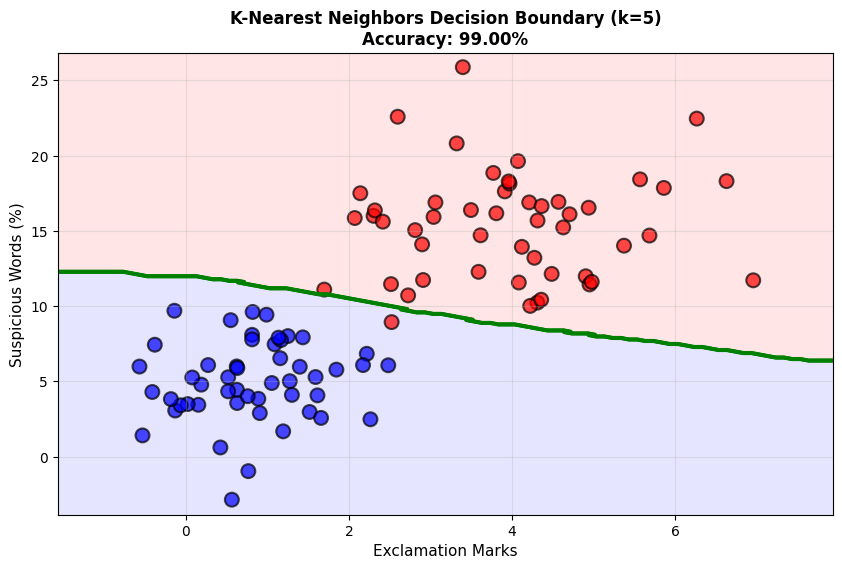

KNN Accuracy: 99.00%


In [27]:
# Train KNN
knn = KNeighborsClassifier(n_neighbors=20)
knn.fit(X, y)

# Calculate accuracy
y_pred_knn = knn.predict(X)
accuracy_knn = accuracy_score(y, y_pred_knn)

# Plot
plot_decision_boundary(knn, X, y,
                       f'K-Nearest Neighbors Decision Boundary (k=5)\nAccuracy: {accuracy_knn:.2%}')
plt.show()

print(f"KNN Accuracy: {accuracy_knn:.2%}")

**Question 9:** The KNN boundary looks different from both logistic regression and decision trees. How would you describe its shape?

*Your answer:* ___The line is jagged and less uniform.

**Question 10:** Try changing n_neighbors=5 to n_neighbors=1 and then n_neighbors=20. How does the boundary change? Which value seems best?

*Your answer:* ___When changing to 1 it becomes more rigged.  When it is changed to 20 it becomes more uniform and straight. I bleive that 20 would be the best.

---

## Part G: Support Vector Machine (Flexible Boundary)

SVM can create linear or non-linear boundaries depending on the kernel:

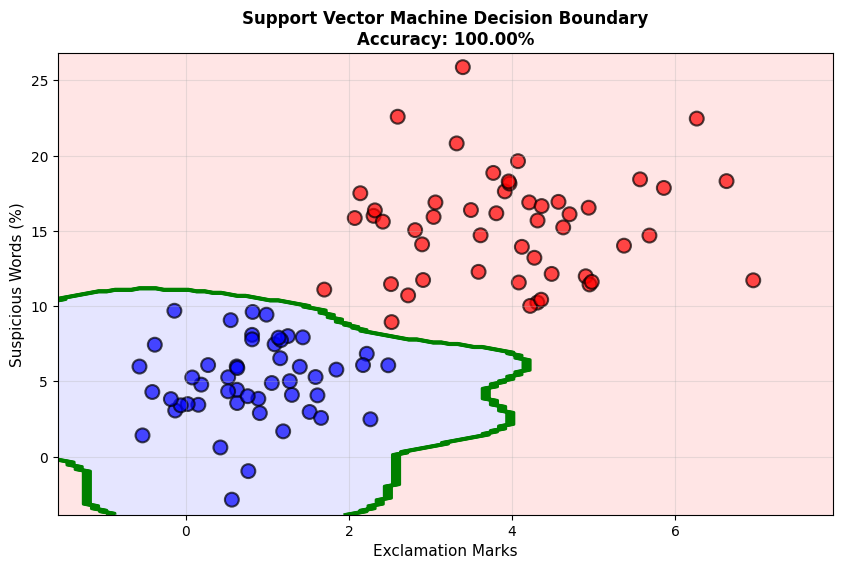

SVM Accuracy: 100.00%


In [29]:
# Train SVM with RBF (radial basis function) kernel
svm = SVC(kernel='rbf', gamma=0.5, random_state=42)
svm.fit(X, y)

# Calculate accuracy
y_pred_svm = svm.predict(X)
accuracy_svm = accuracy_score(y, y_pred_svm)

# Plot
plot_decision_boundary(svm, X, y,
                       f'Support Vector Machine Decision Boundary\nAccuracy: {accuracy_svm:.2%}')
plt.show()

print(f"SVM Accuracy: {accuracy_svm:.2%}")

**Question 11:** The SVM creates a curved boundary. How does it compare to the other non-linear methods (decision tree and KNN)?

*Your answer:* __The boundery consumes the majority of the good data elements (ommitting the spam).

---

## Part H: Side-by-Side Comparison

Let's compare all four classifiers at once:

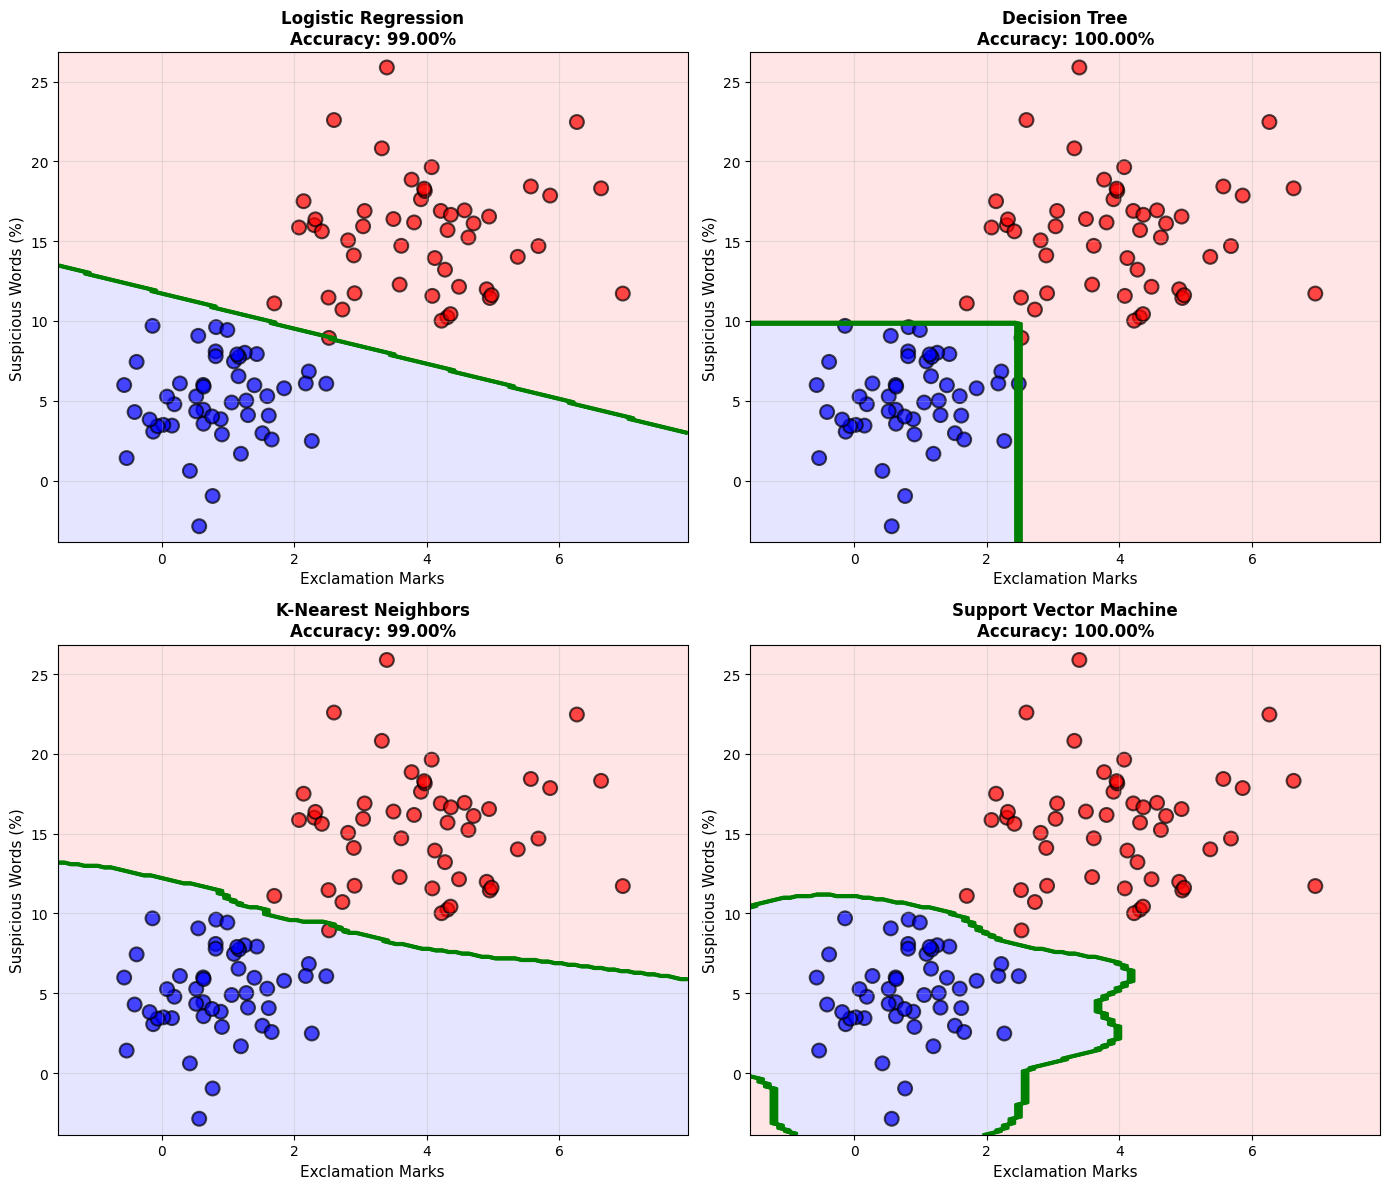

In [31]:
# Train all models
models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(max_depth=4, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Support Vector Machine': SVC(kernel='rbf', gamma=0.5, random_state=42)
}

# Create 2x2 subplot
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

# Plot each model
for idx, (name, model) in enumerate(models.items()):
    model.fit(X, y)
    y_pred = model.predict(X)
    accuracy = accuracy_score(y, y_pred)

    plot_decision_boundary(model, X, y,
                           f'{name}\nAccuracy: {accuracy:.2%}',
                           ax=axes[idx])

plt.tight_layout()
plt.show()

**Question 12:** Which classifier has the highest accuracy? Does the highest accuracy always mean the best model? What other factors should we consider?

*Your answer:* __The decision tree and vesotr machine both have 100% of accuracy. Accuracy is inmportant, but it would also depedn on what story the data is conveying. The logistics regression may be metter for viewing the data in two dimensions.

---

## Part I: Interactive Exploration (Optional)

Experiment with different parameters and observe how boundaries change:

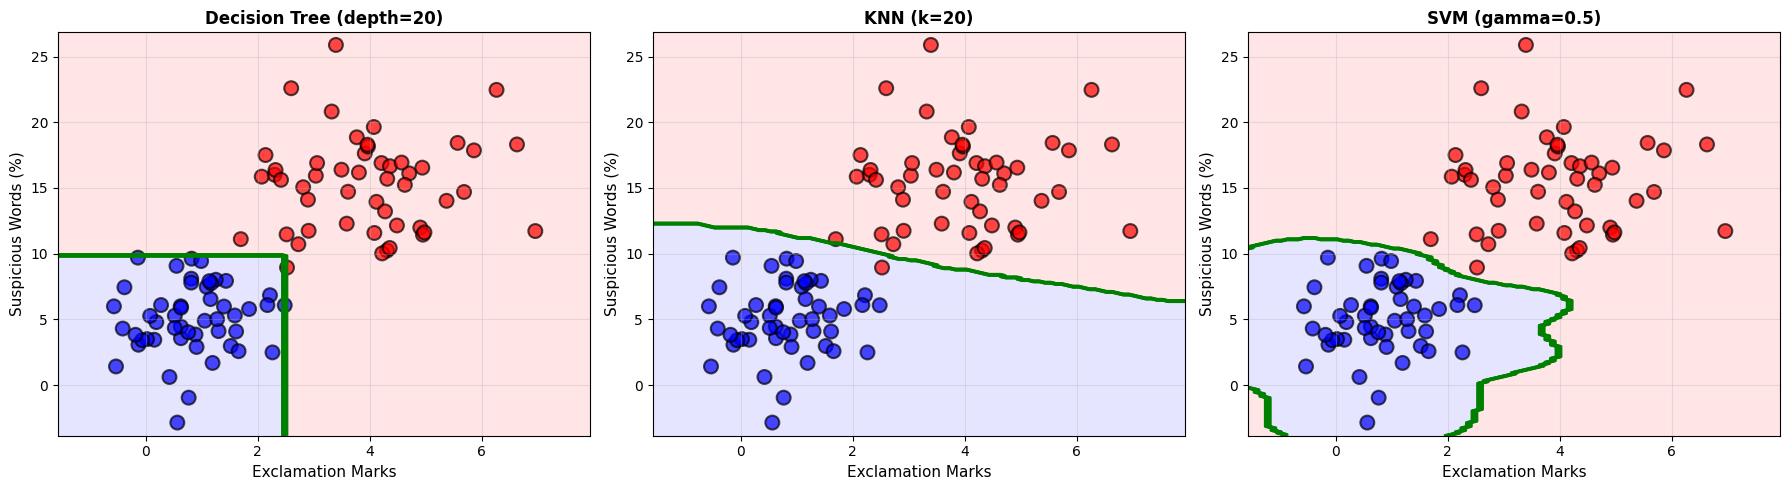

In [35]:
def compare_parameters():
    """
    Interactive function to explore different model parameters.
    Modify the values below and run this cell multiple times!
    """

    # EXPERIMENT WITH THESE VALUES:
    tree_depth = 20      # Try: 1, 3, 5, 10, 20
    knn_neighbors = 20   # Try: 1, 3, 5, 10, 20
    svm_gamma = 0.5     # Try: 0.1, 0.5, 1.0, 5.0

    # Create subplots
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Decision Tree
    tree = DecisionTreeClassifier(max_depth=tree_depth, random_state=42)
    tree.fit(X, y)
    plot_decision_boundary(tree, X, y,
                           f'Decision Tree (depth={tree_depth})',
                           ax=axes[0])

    # KNN
    knn = KNeighborsClassifier(n_neighbors=knn_neighbors)
    knn.fit(X, y)
    plot_decision_boundary(knn, X, y,
                           f'KNN (k={knn_neighbors})',
                           ax=axes[1])

    # SVM
    svm = SVC(kernel='rbf', gamma=svm_gamma, random_state=42)
    svm.fit(X, y)
    plot_decision_boundary(svm, X, y,
                           f'SVM (gamma={svm_gamma})',
                           ax=axes[2])

    plt.tight_layout()
    plt.show()

# Run the comparison
compare_parameters()

**Activity:** Modify the parameter values in the function above and observe:

1. What happens when tree_depth is very small (1) vs. very large (20)?
2. What happens when knn_neighbors is very small (1) vs. very large (20)?
3. What happens when svm_gamma is very small (0.1) vs. very large (5.0)?

*Your observations:* _For the decison tree, the small number (1) is very restrictive and the large number (20) allows for added complexity. For KNN the data lonly looks a the single closest point  with (1) and many neighbors for (20). for SVM 0.1 l;ooks at far reach and 5.0 looks liek close reach. 5.0 could result in overfitting.

---

## Part J: Understanding Overfitting Through Boundaries

Let's visualize how overfitting appears in decision boundaries:

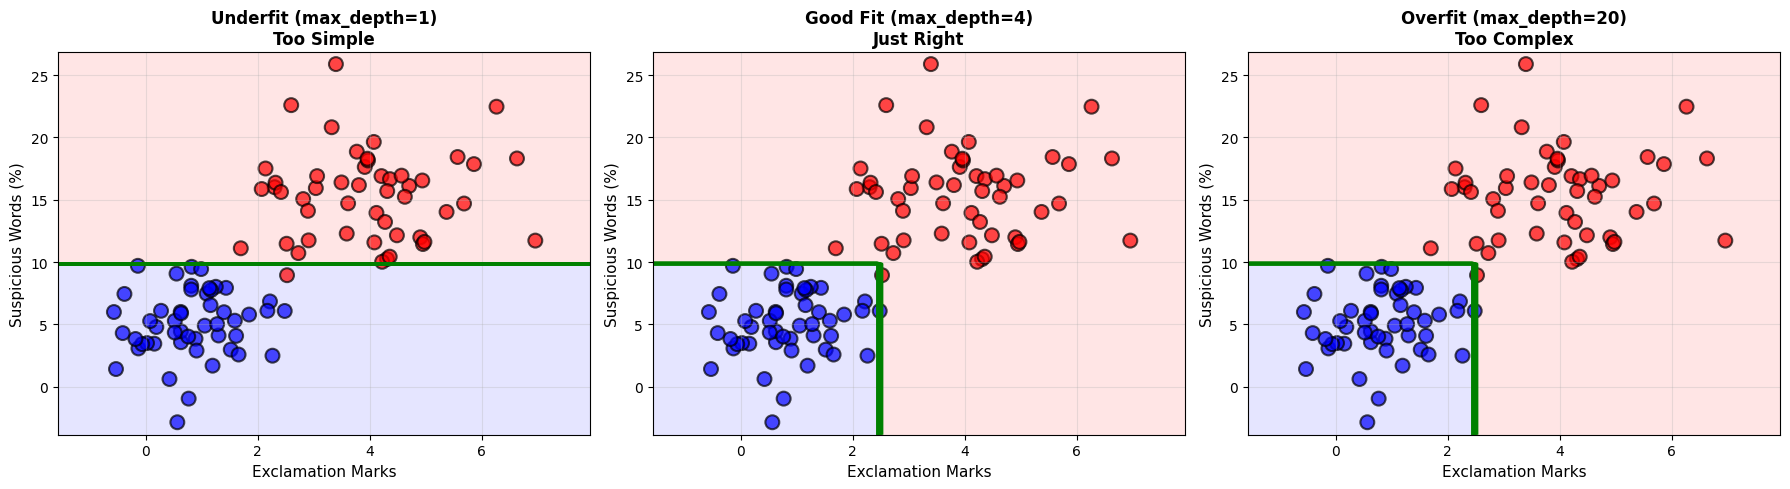

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Underfit (too simple)
simple_tree = DecisionTreeClassifier(max_depth=1, random_state=42)
simple_tree.fit(X, y)
plot_decision_boundary(simple_tree, X, y,
                       'Underfit (max_depth=1)\nToo Simple',
                       ax=axes[0])

# Good fit
balanced_tree = DecisionTreeClassifier(max_depth=4, random_state=42)
balanced_tree.fit(X, y)
plot_decision_boundary(balanced_tree, X, y,
                       'Good Fit (max_depth=4)\nJust Right',
                       ax=axes[1])

# Overfit (too complex)
complex_tree = DecisionTreeClassifier(max_depth=20, random_state=42)
complex_tree.fit(X, y)
plot_decision_boundary(complex_tree, X, y,
                       'Overfit (max_depth=20)\nToo Complex',
                       ax=axes[2])

plt.tight_layout()
plt.show()

**Question 13:** Look at the three decision boundaries above. Which one looks most reasonable? Why might the "overfit" model perform poorly on new, unseen emails?

*Your answer:* __Overfitting might ignore anomalies with new data sets. It may make poor data "fit".

---

## Part K: Complete Code Summary

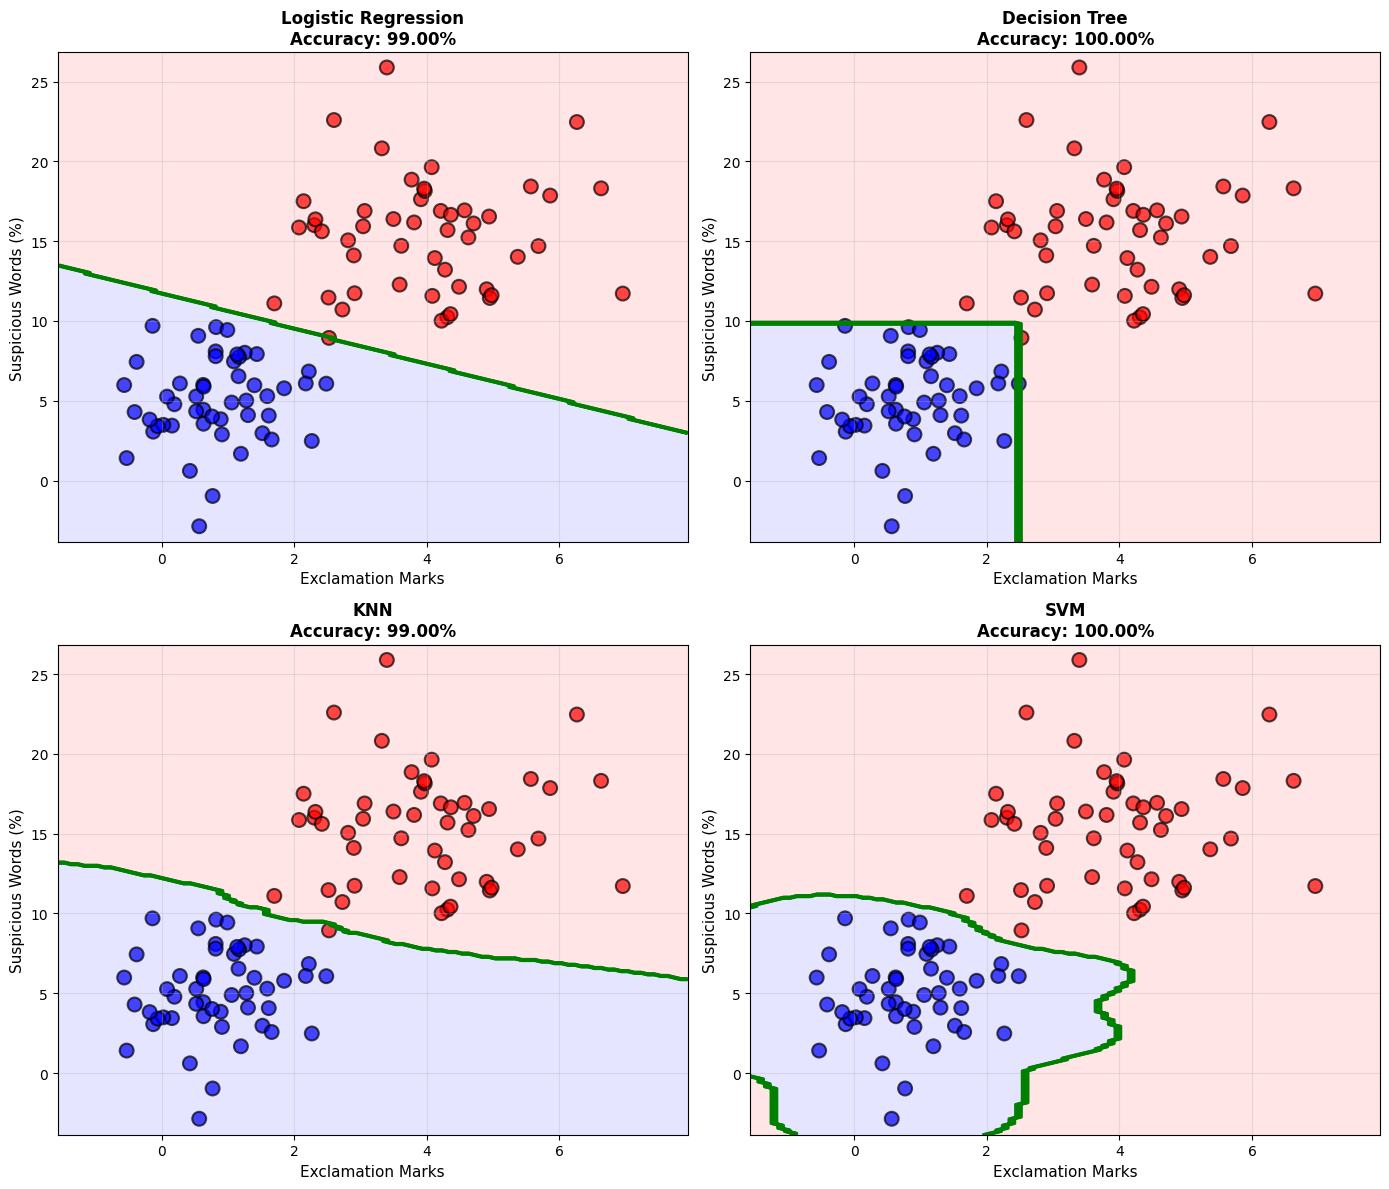

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score # Added this import

# Generate data
np.random.seed(42)
legitimate = np.column_stack([
    np.random.normal(1, 0.8, 50),
    np.random.normal(5, 3, 50)
])
sap = np.column_stack([
    np.random.normal(4, 1.2, 50),
    np.random.normal(15, 4, 50)
])
X = np.vstack([legitimate, sap])
y = np.array([0]*50 + [1]*50)

# Train models and visualize
models = [
    ('Logistic Regression', LogisticRegression()),
    ('Decision Tree', DecisionTreeClassifier(max_depth=4)),
    ('KNN', KNeighborsClassifier(n_neighbors=5)),
    ('SVM', SVC(kernel='rbf', gamma=0.5))
]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten() # Flatten the 2x2 array of axes for easy indexing
for idx, (name, model) in enumerate(models):
    model.fit(X, y)
    y_pred = model.predict(X)
    accuracy = accuracy_score(y, y_pred) # Calculate accuracy

    # Plot using helper function
    ax = axes[idx]
    plot_decision_boundary(model, X, y,
                           f'{name}\nAccuracy: {accuracy:.2%}', # Pass accuracy to title
                           ax=ax)

plt.tight_layout() # Added for better layout
plt.show()

---

## Part L: Reflection and Extensions

### Reflection Questions

1. **Linear vs. Non-Linear:** When would you prefer a linear decision boundary (like logistic regression) over a non-linear one? What are the trade-offs? Linear regressions is ideal when there is a clear boundry between data elements. Linear is also best when there are fewer data elements and more direct correlation between the numbers.
2. **Geometric Intuition:** In your own words, explain what a decision boundary represents geometrically. How does a model "know" which side of the boundary a new point belongs to? Geometrical representation creates decision boundaries that devides data into distince data. The model uses the other data elements to define it relationship on the chart.
3. **Dimensionality:** We used 2D data for easy visualization. How would decision boundaries work in 3D space? What about 100D space? 3D visaulizations are often difficult to visualize. Our brain can easily conceptualize two dimensions. Adding one more dimension makes it more challenging, but is still doable. 99 dimensions would be impossible to conceputatize.
4. **Real-World Application:** Beyond spam detection, name three other classification problems where visualizing decision boundaries would be helpful. 1) Hospital error rates per MD experience. 2) Grades on SAT per GPA. 3) Credit scores based on credit record.

### Extension Challenges (5 points Extra Credit Each)

**Challenge 1 - New Data:** Create your own 2D classification dataset (e.g., student admission based on test scores and GPA) and visualize decision boundaries.

**Challenge 2 - Multiple Classes:** Modify the code to handle 3 classes instead of 2. How do decision boundaries change?

**Challenge 3 - Interactive Prediction:** Create a function where you can click on the plot to add a new point and see which class the model predicts.

**Challenge 4 - Comparison Metrics:** Beyond accuracy, calculate precision, recall, and F1-score for each classifier. Which metric matters most for spam detection?

**Challenge 5 - Real Boundaries:** Research the actual features used in modern spam filters. Are decision boundaries still visualizable in high-dimensional space?

---

## Exercise Key Takeaways

✓ **Decision boundaries** visually show how classifiers separate classes✓ **Linear models** (logistic regression) create straight boundaries✓ **Non-linear models** (decision trees, KNN, SVM) create curved boundaries✓ **Model complexity** affects boundary shape and overfitting risk✓ **Visualization** builds intuition but only works well in 2D/3D✓ **Different algorithms** make different geometric assumptions✓ **Parameter tuning** dramatically changes decision boundaries

## Binary vs. Multi-Class Classification

Linear classification problems naturally divide into two fundamental types based on the number of possible outcomes, and understanding this distinction will help you choose appropriate techniques and set realistic expectations for different types of problems you'll encounter in practice.

Binary classification encompasses many of the most important and straightforward real-world applications. These problems involve choosing between exactly two alternatives: spam or not spam, approve or deny, disease present or absent, fraudulent or legitimate. The mathematical framework aligns perfectly with this structure because a single hyperplane can effectively separate two classes, and a single probability threshold can determine the final decision. This simplicity makes binary classification both computationally efficient and conceptually clear, which explains why it often serves as the starting point for understanding more complex classification scenarios.

The decision-making process in binary classification follows an intuitive pattern that builds directly on the concepts you've already learned. The linear function produces a numerical score based on input features, the sigmoid transformation (in logistic regression) converts this score to a probability between 0 and 1, and a threshold, usually set at 0.5, determines the final classification. If the probability exceeds the threshold, you predict the positive class; if it falls below the threshold, you predict the negative class. This straightforward process makes binary classification easy to implement, debug, and explain to stakeholders.

Multi-class classification extends these principles to handle problems with three or more possible outcomes, but this extension introduces both mathematical complexity and practical challenges that require more sophisticated approaches. Customer segmentation might categorize clients as "budget-conscious," "premium," or "luxury" buyers. Image recognition systems classify objects into dozens or hundreds of categories. Medical diagnosis often involves distinguishing between multiple possible conditions rather than simple presence-or-absence decisions.

The fundamental challenge with multi-class problems lies in the geometric limitation of linear boundaries. A single hyperplane can only separate space into two regions, but multi-class problems require dividing space into three or more regions. This mathematical constraint means you need either multiple hyperplanes working together or alternative mathematical frameworks that can handle multiple categories simultaneously.

Several strategic approaches address multi-class classification using linear methods, each with distinct advantages and trade-offs. The "one-vs-rest" approach trains separate binary classifiers for each class against all other classes combined, then selects the class with the highest confidence score for final predictions. This method is computationally efficient and leverages your existing binary classification knowledge, but it can struggle when classes overlap significantly or when the "rest" category becomes too diverse.

The "one-vs-one" method trains binary classifiers for every possible pair of classes, then uses voting mechanisms to determine final predictions. If you have four classes, you'd train six binary classifiers (A vs B, A vs C, A vs D, B vs C, B vs D, C vs D), then let these classifiers "vote" on new examples. This approach can achieve higher accuracy with complex data patterns, but the computational cost grows rapidly as the number of classes increases.

Multinomial logistic regression extends logistic regression directly to multiple classes using the softmax transformation instead of the sigmoid function. The softmax function ensures that predicted probabilities across all classes sum to 1, creating a proper probability distribution over all possible outcomes. This approach provides theoretically cleaner solutions and meaningful probability estimates for each class, making it particularly valuable when you need confidence measures for your predictions.

The evaluation of multi-class classifiers requires more sophisticated metrics that account for the complexity of multiple possible outcomes. Overall accuracy remains useful but can hide significant problems with specific classes, a model might achieve 90% accuracy while completely failing to recognize one important category. Class-specific precision and recall help identify which categories the model handles well or poorly, enabling targeted improvements to address specific weaknesses.

Confusion matrices become larger and more informative in multi-class scenarios, showing specific patterns of classification errors across all categories. These matrices reveal not just how often the model makes mistakes, but what types of mistakes it makes. Understanding whether misclassifications occur randomly or follow patterns helps guide improvements to both the model and the underlying data collection process.

The choice between binary and multi-class formulations often depends on your specific application context and available data. Sometimes naturally multi-class problems can be decomposed into sequences of binary decisions through hierarchical approaches. A medical diagnosis system might first classify symptoms as "neurological" or "not neurological," then apply specialized classifiers within each category. Other times, binary formulations can be extended to multi-class through ensemble methods that combine multiple binary classifiers.

Understanding both approaches provides the flexibility to tackle diverse classification challenges and choose the most appropriate method for each specific problem. The key insight is that multi-class classification isn't simply "binary classification with more categories,"  it introduces genuine mathematical and practical complexities that require thoughtful approach selection and more sophisticated evaluation strategies.

![image8.jpg](assets/image8.jpg)

### Evaluation metrics: Beyond accuracy

*“What gets measured gets managed ,  even when it’s pointless to measure and manage it,**and even if it harms the purpose of the organisation to do so”.*

*From “Dysfunctional Consequences of Performance Measurements” ~ V. F. Ridgway, 1956*

While accuracy provides a useful starting point for evaluating classification models, it often tells an incomplete story about how well your model will perform in the real world. Think of accuracy like looking at a company's revenue without examining profit margins or expenses, you're getting important information, but you're missing crucial details that determine whether the business actually works.

Understanding comprehensive evaluation metrics becomes essential when you realize that different types of prediction errors carry dramatically different consequences. A model that misses detecting fraud costs your bank money in a completely different way than one that flags legitimate transactions as suspicious. The confusion matrix and derived metrics like precision, recall, and F1-score help you understand these nuances and build more reliable classification systems.

The Confusion Matrix: Your Model's Full Financial Statement

The confusion matrix serves as your model's complete performance breakdown, revealing patterns that overall accuracy might completely obscure. For binary classification, this matrix shows you four critical pieces of information:

- true positives (correct positive predictions)
- true negatives (correct negative predictions)
- false positives (incorrect positive predictions)
- false negatives (missed positive cases)

Consider a practical example that illustrates why this detailed view matters so much. Imagine you're building a medical screening test for a disease that affects only 1% of the population. A simplistic model that always predicts "no disease" would achieve an impressive 99% accuracy. At first glance, this seems like excellent performance that any stakeholder would celebrate.

However, examining the confusion matrix reveals a devastating flaw: this model produces zero true positives and zero false negatives because it never predicts the positive class at all. Despite its high accuracy, the model is completely useless for its intended purpose of identifying patients who need treatment. This example demonstrates why accuracy alone can be deeply misleading, particularly when dealing with imbalanced datasets where one class significantly outnumbers the other.